<a href="https://colab.research.google.com/github/VladousSparrowous/OpenML/blob/main/Time_Series_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ДОМАШНЕЕ ЗАДАНИЕ ПО ВРЕМЕННЫМ РЯДАМ
Построение вероятностной модели (реального/смоделированного)  временного ряда

1.	Используя процедуру Доладо-Дженкинса-Сосвилла -Риверо, выяснить, относится ли наблюдаемый ряд к типу TSP.
2.	Для ряда типа TSP оценить  по МНК детерминированную составляющую ряда.
3.	Детрендировать ряд.  
4.	Провести идентификацию случайной составляющей ряда, выбрав в качестве базовых 2-3 подходящие модели.
5.	Оценить параметры выбранных моделей.
6.	Используя информационные критерии Акаике и Шварца, выбрать адекватную модель.
7.	Провести диагностику остатков.
8.	Построить прогноз на один шаг.


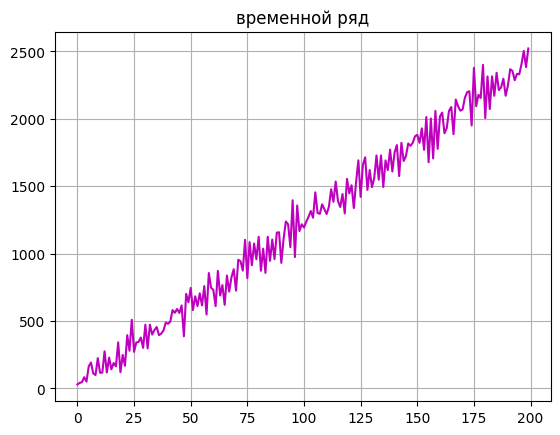

In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt


Time_Series = 0
with open('/content/drive/MyDrive/ИДЗ временные ряды (данные)  30 вариантов МАГОЛЕГО.txt', encoding='cp1251') as file:
    for line in file:
        if 'Вариант 12' == line.strip():
            Time_Series_str = next(file).strip()
            Time_Series = np.array(list(map(float, Time_Series_str.split(','))))
            break
plt.title('временной ряд')
plt.plot(Time_Series, 'm')
plt.grid()

In [ ]:
p = 0.2
threshold =int((len(Time_Series) - 1) * (1 - p))
Time_Series_train = Time_Series[:threshold]
Time_Series_test = Time_Series[threshold:]

После отрисовки ряда, уже можно предположить что он либо с трендом, либо нестационарен.

Проводим проверку в соответсвии с процедурой Доладо-Дженкинса-Сосвилла -Риверо.

# $\S~1$ процедура Доладо-Дженкинса-Сосвилла -Риверо.

---
# (шаг 1)  Dickey-Fuller test
С помощью модуля statsmodels.tsa.stattools проводим тест adfuller, параметр 'ct' значит, что проверяется модель с трендом.

Модель в общем виде:

$\Delta X_t = \alpha + \beta t + \gamma X_{t-1} + \sum_{i=1}^{p} \delta_i \Delta X_{t-i} + \varepsilon_t$

тест проверяет:
$$
\text{H}_0: \gamma = 0 \quad \text{(ряд имеет единичный корень, DSP)}\\
\text{H}_1: \gamma < 0 \quad \text{(ряд стационарен, TSP если есть тренд)}
$$

Так же тест автоматически подбирает количество лагов на основе информационного критерия (по умолчанию AIC)


In [ ]:
from statsmodels.tsa.stattools import adfuller

result_step_1 = adfuller(Time_Series, regression='ct', regresults=True)

def perform_DF(result):
    titles = [
            'adf (float) – The test statistic.',
            'pvalue (float) – MacKinnon’s approximate p-value based on MacKinnon (1994, 2010).',
            'usedlag (int) – The number of lags used.',
            'nobs (int) – The number of observations used for the ADF regression and calculation of the critical values.',
            'critical values (dict) – Critical values for the test statistic at the 1 %, 5 %, and 10 % levels. Based on MacKinnon (2010).',
            'icbest (float) – The maximized information criterion if autolag is not None.',
            'resstore (ResultStore, optional) – A dummy class with results attached as attributes.'
            ]

    # titles из документации https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html#statsmodels.tsa.stattools.adfuller

    for i in zip(titles, result):
        print(*i, sep='\n | \n V \n')
        print('=' * 60)

perform_DF(result_step_1[:-1])

adf (float) – The test statistic.
 | 
 V 
-24.637492830538594
pvalue (float) – MacKinnon’s approximate p-value based on MacKinnon (1994, 2010).
 | 
 V 
0.0
usedlag (int) – The number of lags used.
 | 
 V 
{'1%': np.float64(-4.004997848936356), '5%': np.float64(-3.4327862452981046), '10%': np.float64(-3.140144918368515)}


# интерпретация результатов
* $$
\text{adf} = -24.637
$$
Что намного меньше критического значения даже на уровне значимости 1%.
Следовательно можно отклонить нулевую гипотезу.


* Лагов не было добавлено, значит автокорреляция в остатках отсутствует и модель имеет вид:
$$
\Delta X_t = \alpha + \beta t + \gamma X_{t-1} + \varepsilon_t
$$
иначе:
$$
X_t = \alpha + \beta t + \gamma' X_{t-1} + \varepsilon_t
$$

Но чтобы окончательно утверждать, что ряд **TSP**, нужно проверить **значимость тренда β** через t-тест.

---

# (шаг 2) t-test

Нужно проверить:

$$
H_0: \beta = 0 \quad \text{(тренд незначим)}\\
H_1: \beta \neq 0 \quad \text{(тренд значим)}
$$

Для этого в adfuller можно задать параметр regresults=True, благодаря этому он вернёт модель линейной регресси, содержащую summary.
В ней даны оценки параметров методом МНК, статистика по t-test и многое другое.


In [ ]:
model = result_step_1[-1].resols
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                     303.5
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           9.49e-61
Time:                        01:02:53   Log-Likelihood:                -1153.6
No. Observations:                 199   AIC:                             2313.
Df Residuals:                     196   BIC:                             2323.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -1.5146      0.061    -24.637      0.0

# интерпретация результатов

* t-статистика для β($x_2$) = 24.442 > 1.96,
p-value = 0.000 меньше 0.05

следовательно нулевая гипотеза H₀: β = 0 отвергается.

Временной ряд имеет тип TSP и процедура на этом заканчивается.

---

# $\S~2$ Для ряда типа TSP оценить по МНК детерминированную составляющую ряда.

Детерминированна часть $X_t$ это линейный тренд $f(t)$:
$$
X_t = f(t) + u_t,\\
f(t) = ϴ_0 + ϴ_1 t\\
\text{$u_t$ - стационарная случайная компонента}
$$
Для его нахождения используем OLS из модуля statsmodels.api, которая методом МНК определяет коэффиценты.

In [ ]:
import statsmodels.api as sm

n = len(Time_Series)
time = np.arange(n)
X = sm.add_constant(time)
model_ols = sm.OLS(Time_Series, X).fit()
model_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.123e+04
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          2.45e-176
Time:                        23:21:29   Log-Likelihood:                -1189.5
No. Observations:                 200   AIC:                             2383.
Df Residuals:                     198   BIC:                             2390.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         21.4198     13.115      1.633      0.104      -4.443      47.283
x1            12.0813      0.114    105.970      0.000      11.857      12.306
==============================================================================
Omnibus:                        0.562   Durbin-Watson:                   3.018
Prob(Omnibus):                  0.755   Jarque-Bera (JB):                0.699
Skew:                          -0.085   Prob(JB):                        0.705
Kurtosis:                       2.766   Cond. No.                         229.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.123e+04
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          2.45e-176
Time:                        23:21:29   Log-Likelihood:                -1189.5
No. Observations:                 200   AIC:                             2383.
Df Residuals:                     198   BIC:                             2390.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         21.4198     13.115      1.633      0.104      -4.443      47.283
x1            12.0813      0.114    105.970      0.000      11.857      12.306
==============================================================================
Omnibus:                        0.562   Durbin-Watson:                   3.018
Prob(Omnibus):                  0.755   Jarque-Bera (JB):                0.699
Skew:                          -0.085   Prob(JB):                        0.705
Kurtosis:                       2.766   Cond. No.                         229.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# интерпретация результатов
Из summary() можно получить оценки коэффициентов $ \hat{ϴ}_0 = 21.4198, \hat{ϴ}_1 = 12.0813$ и тогда линейный тренд оценивается:
$$
\hat{f(t)} = 21.4198 + 12.0813 t
$$

---

# $\S~3$ Детрендировать ряд.

Для этого вычитаем из изначального ряда полученную оценку тренда.

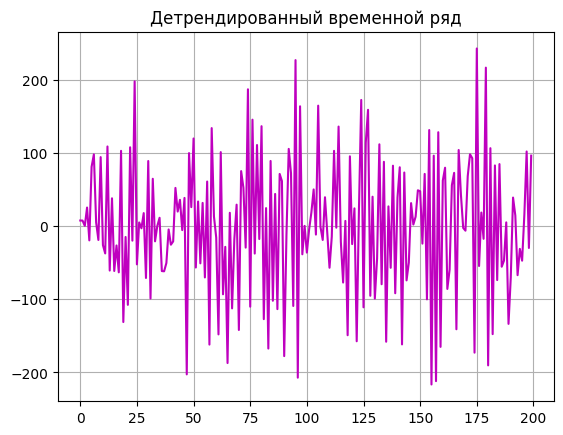

In [ ]:
detrended_TS = Time_Series.copy() - model_ols.predict(X)

plt.title('Детрендированный временной ряд')
plt.plot(detrended_TS, 'm')
plt.grid()

# $\S~4$ Провести идентификацию случайной составляющей ряда, выбрав в качестве базовых 2-3 подходящие модели.

Для проведения идентификации строим Autocorrelation Function и Partial Autocorrelation Function.(трубка для уровня доверия 0.95)

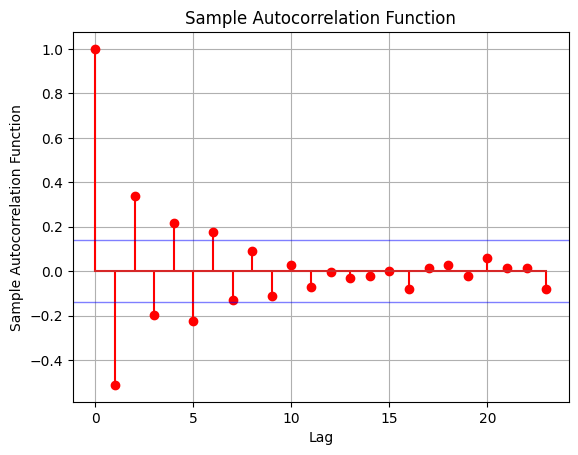

In [ ]:
from statsmodels.tsa.stattools import acf

def draw_cf(cf, name):

    plt.stem(cf, 'r')
    plt.title(name)

    # добавление границ трубки
    k = 1.96 / (n ** (1/2))
    plt.axhline(y=k, color='blue', alpha=0.5, linestyle='-', linewidth=1)
    plt.axhline(y=-k, color='blue', alpha=0.5, linestyle='-', linewidth=1)

    plt.xlabel("Lag")
    plt.ylabel(name)
    plt.grid()
    plt.show()

ACF = acf(detrended_TS)
draw_cf(ACF, 'Sample Autocorrelation Function')

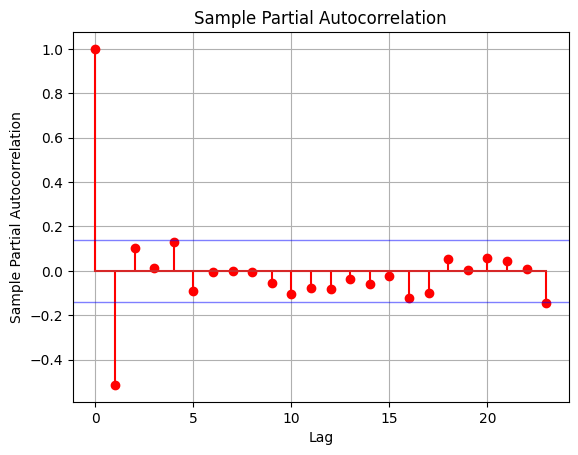

In [ ]:
from statsmodels.tsa.stattools import pacf

PACF = pacf(detrended_TS)
draw_cf(PACF, 'Sample Partial Autocorrelation')

# интерпретация результатов

* Начиная с 7го все значения acf лежат в трубке, это ещё раз подтверждает стационарность остатка. Для pacf аналогично с учётом уровня доверия,

* acf спадает и заходит в интервал только с 7го, а pacf резко обрывается уже после второго лага, можно предположить AR(2) или AR(1), возможно ARMA(1, 1).

---

# $\S~5$ Оценить параметры выбранных моделей.

AR процессы оцениваются с помощью Yule - Walker. ARMA через ARIMA.

In [ ]:
from statsmodels.tsa.stattools import yule_walker

params_AR_2, sigma = yule_walker(detrended_TS, order=2, method='mle')
print("Оцененные параметры AR(2):", *params_AR_2)

params_AR_1, sigma = yule_walker(detrended_TS, order=1, method='mle')
print("Оцененные параметры AR(1):", *params_AR_1)

Оцененные параметры AR(2): -0.4589682651385203 0.1031422232789795
Оцененные параметры AR(1): -0.5117514471653942


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model_ARMA = ARIMA(detrended_TS, order=(1, 0, 1), trend='n')
results_ARMA = model_ARMA.fit()

print("Оцененные параметры ARMA(1, 1):", *results_ARMA.params[:-1])

Оцененные параметры ARMA(1, 1): -0.6656822691276197 0.2123056109429614


# $\S~6$ Используя информационные критерии Акаике и Шварца, выбрать адекватную модель.

In [ ]:
model_AR_2 = ARIMA(detrended_TS, order=(2, 0, 0), trend='n')
results_AR_2 = model_AR_2.fit()

print(f"\nAR(2) результаты:")
print(f"AIC: {results_AR_2.aic:.2f}")
print(f"BIC: {results_AR_2.bic:.2f}")

model_AR_1 = ARIMA(detrended_TS, order=(1, 0, 0), trend='n')
results_AR_1 = model_AR_1.fit()

print(f"\nAR(1) результаты:")
print(f"AIC: {results_AR_1.aic:.2f}")
print(f"BIC: {results_AR_1.bic:.2f}")

print(f"\nARMA результаты:")
print(f"AIC: {results_ARMA.aic:.2f}")
print(f"BIC: {results_ARMA.bic:.2f}")


AR(2) результаты:
AIC: 2322.05
BIC: 2331.95

AR(1) результаты:
AIC: 2322.16
BIC: 2328.75

ARMA результаты:
AIC: 2321.99
BIC: 2331.88


# интерпретация результатов
Выбирается AR(1), так как у неё наименьшие BIC, AIC почти одинаковый.

---

# $\S~7$ Провести диагностику остатков.

Вычитаем из детрендированного ряда AR составляющую для получения остатков.
Смотрим на Autocorrelation Function и проверяем гипотезу о белошумности остатков с помощью критерия Люнга-Бокса.

$$
H_0 : \rho_\varepsilon(1) = \cdots = \rho_\varepsilon(20) = 0\\
H_A : \sum_{j=1}^{20} \rho_\varepsilon^2(j) > 0
$$

In [ ]:
eps = detrended_TS[1:] - params_AR_1[0] * detrended_TS[:-1]

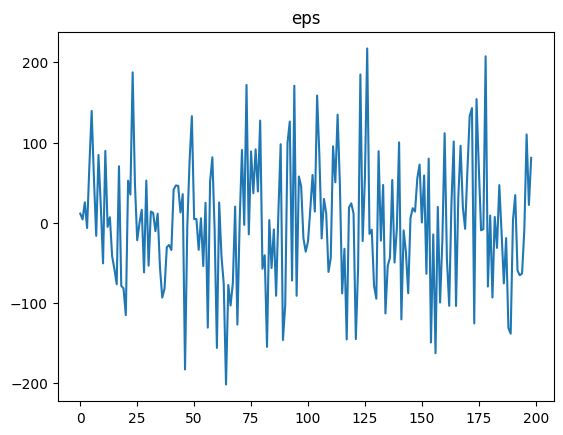

In [ ]:
plt.title('eps')
plt.plot(eps)
plt.show()

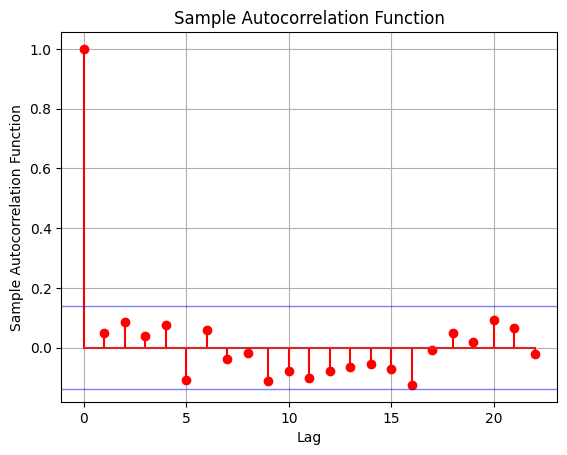

In [ ]:
ACF_eps = acf(eps)
draw_cf(ACF_eps, 'Sample Autocorrelation Function')

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import numpy as np

lb_test = acorr_ljungbox(eps, lags=[20], model_df=1)
print(lb_test)

      lb_stat  lb_pvalue
20  22.980462   0.238203


# интерпретация результатов
Статистика получилась 22.980462 < $χ^2(19)$ = 30.144.
Следовательно гипотеза о белошумности принимается.

---

#$\S~8$	Построить прогноз на один шаг.
Вот запись в LaTeX с условным математическим ожиданием (среднеквадратически оптимальным прогнозом) для вашей модели:

## Основная формула

Для модели
$$
X_t = \alpha + \beta t + \gamma X_{t-1} + \varepsilon_t,
$$
где $\varepsilon_t$ — белый шум с
$$
E[\varepsilon_t ] = 0,
$$
 среднеквадратически оптимальный прогноз на один шаг вперед имеет вид:

$$
\hat{X}_{200} = E\left[X_{200} \mid X_{199}, X_{198}, \ldots, X_0\right] = \alpha + \beta t + \gamma X_{199}.
$$



In [ ]:
X_200 = (1 - params_AR_1[0]) * model_ols.predict([[1., 200]])[0] + params_AR_1[0] * Time_Series[-1]
print('ско прогноз X_200: ', X_200)

ско прогноз X_200:  2394.6284372730906


In [ ]:
predict_Series = Time_Series.copy()

def next_n(last_step, n):
    global predict_Series
    X_next = (1 - params_AR_1[0]) * model_ols.predict([[1., last_step]])[0] + params_AR_1[0] * predict_Series[-1] + np.random.normal(loc=0, scale=70)
    predict_Series = np.hstack((predict_Series, [X_next]))
    if n == 1:
        return
    else:
        next_n(last_step + 1, n - 1)

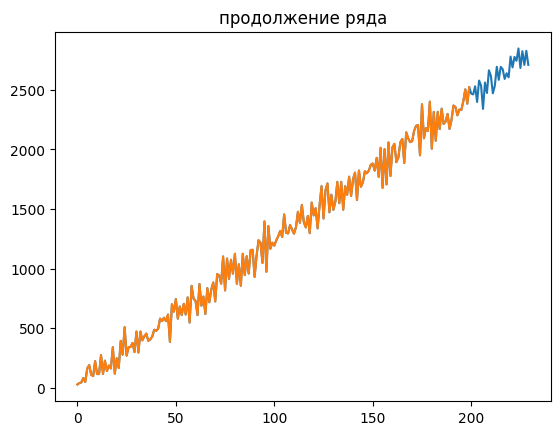

In [ ]:
next_n(200, 30)
plt.plot(predict_Series)
plt.plot(Time_Series)
plt.title('продолжение ряда')
plt.show()